# [TEMP] 3. Scheduling: Chunked Prefill and the Prefill–Decode Interference

Lecture 2 kept things simple: every request was either prefill-only or
decode-only. Real requests have both phases, so a serving system constantly faces
the following situation:

> Several users are in the middle of receiving their answers (their requests are
> **decoding**). A new request with a long prompt arrives and needs a **prefill**.
> What should the scheduler run next?

This sounds like a small detail, but the answer decides whether the new user
waits seconds for their first token, or the existing users see their text
**stall** mid-sentence. In this lecture we try the obvious answers first, see why
each of them fails, and then build up to **chunked prefill**, the technique used
by modern serving systems such as vLLM (Kwon et al., SOSP '23) and SGLang
(Zheng et al., NeurIPS '24).

:::{admonition} Learning goals
- Explain why the three "obvious" ways to schedule a new prefill (make it wait,
  pause decodes, or batch them together) each hurt either TTFT or TPOT.
- Explain how chunked prefill bounds the length of every step, and why the decodes
  that share a step with a prefill chunk are almost free.
- Use `chunk_size` to trade TTFT against TPOT, and explain why the trade-off
  becomes sharper under heavy load.
:::

## Setup

Same setup as {doc}`01-prefill-and-decode`: Qwen2.5-32B-Instruct on two A100s.

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # outside the course repo (e.g. Colab): fetch the package
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

SYSTEM = dict(model="Qwen/Qwen2.5-32B-Instruct", device="a100", tensor_parallel=2)

Simulator ready at /home/user/.llm-systems-wo-gpus/backend


## The scenario

Throughout the first half of this lecture we use one small, concrete scenario:

- At $t = 0$, **16 chat users** send a short prompt (256 tokens) and start
  receiving a 256-token answer.
- At $t = 2$ s, while all 16 are still decoding, a **document** request arrives:
  a 3,800-token prompt (e.g., "summarize this report") with a 32-token answer.

Recall the two numbers that matter from lectures 1 and 2. A decode step for the
16 chat users takes about 40 ms, because decode is memory-bound and batching 16
requests costs about the same as one. Prefilling 3,800 tokens takes much longer,
because prefill is compute-bound and its cost grows with the prompt length. Let's
measure both:

In [2]:
chat = lsg.simulate(**SYSTEM, qps=None, num_requests=16, prefill_tokens=256, decode_tokens=256)
doc = lsg.simulate(**SYSTEM, qps=None, num_requests=1, prefill_tokens=3800, decode_tokens=1,
                   chunk_size=4096)
decode_step = chat.tpot.median()   # one decode step for the 16 chat users
prefill_time = doc.ttft.iloc[0]    # one 3,800-token prefill, alone on the GPUs
chat_done = chat.e2e.max()         # when the last chat user finishes (no document)
print(f"decode step (16 users): {1e3 * decode_step:.0f} ms")
print(f"prefill of 3,800 tokens: {1e3 * prefill_time:.0f} ms")
print(f"chat users finish at:    {chat_done:.1f} s")

decode step (16 users): 39 ms
prefill of 3,800 tokens: 652 ms
chat users finish at:    10.7 s


The prefill is about 16× longer than a decode step. Whatever the scheduler does,
this 650 ms of work has to be done somewhere. The question is **who waits for it**.

To run the scenario in the simulator, two `simulate` arguments help:
`arrival_times` gives every request an exact arrival time (instead of random
arrivals at a given `qps`), and `keep_steps=True` records every forward pass
("step") the GPUs run, which we read back from `r.steps`.

In [3]:
def run_scenario(chunk_size):
    """16 chat users from t=0, plus a 3,800-token document arriving at t=2 s."""
    r = lsg.simulate(**SYSTEM, num_requests=17, chunk_size=chunk_size, keep_steps=True,
                     prefill_tokens=[256] * 16 + [3800], decode_tokens=[256] * 16 + [32],
                     arrival_times=[0] * 16 + [2.0])
    steps = r.steps
    # The GPUs are never idle in this scenario, so each step starts when the previous one ends.
    steps["end (s)"] = steps["batch_execution_time"].cumsum()
    steps["start (s)"] = steps["end (s)"] - steps["batch_execution_time"]
    return r, steps

Before running the simulator, we will sketch each policy as a diagram. Each row
is one request: three of the 16 chat users, and the document. Each box is the
work a request does in one step: a **decode** box ends with one new token, a
**prefill** box processes the prompt, and a gray box means the request is
**waiting** while the GPUs run something else. The diagrams are schematic: the
real prefill is about 16 decode steps long, not 4. (Click to show the code that
draws them, if you are curious.)

In [4]:
#@title Diagram code (schematic, not to scale)
from matplotlib.patches import Patch

def draw_schedule(policy, title):
    """Sketch one scheduling policy. Time unit: one decode step."""
    PREFILL, CHUNK_STEP, N_CHUNKS = 4.0, 1.5, 3   # whole prefill, one chunked step, chunks
    ARRIVAL, DOC_TOKENS = 2.0, 4
    left = [6, 7, 8]                  # output tokens still to produce, per chat user
    DOC = len(left)                   # row of the document
    boxes, t, chunks_done, doc_left, first_token = [], 0.0, 0, DOC_TOKENS, None
    while any(left) or doc_left:
        need_prefill = t >= ARRIVAL and chunks_done < N_CHUNKS
        chat, doc, length = "decode", None, 1.0
        if need_prefill and policy == "wait" and any(left):
            doc = "waiting"
        elif need_prefill and policy == "chunked":
            doc, length = f"chunk {chunks_done + 1}", CHUNK_STEP
        elif need_prefill:
            doc, length = "prefill (whole prompt)", PREFILL
            chat = "paused" if policy == "pause" else "decode"
        elif chunks_done == N_CHUNKS and doc_left:
            doc = "decode"
        for i, n in enumerate(left):
            if n:
                boxes.append((i, t, length, chat))
                left[i] -= chat == "decode"
        if doc:
            boxes.append((DOC, t, length, doc))
            if doc.startswith(("prefill", "chunk")):
                chunks_done = N_CHUNKS if doc.startswith("prefill") else chunks_done + 1
                if chunks_done == N_CHUNKS:
                    first_token, doc_left = t + length, doc_left - 1
            elif doc == "decode":
                doc_left -= 1
        t += length

    color = {"decode": "C1", "paused": "0.85", "waiting": "0.85"}
    fig, ax = plt.subplots(figsize=(10, 2.7))
    merged = []                      # merge a row's consecutive waiting boxes into one
    for b in boxes:
        prev = [j for j, m in enumerate(merged) if m[0] == b[0]]
        if prev and b[3] == merged[prev[-1]][3] == "waiting":
            row, start, length, kind = merged[prev[-1]]
            merged[prev[-1]] = (row, start, length + b[2], kind)
        else:
            merged.append(b)
    for row, start, length, kind in merged:
        ax.barh(row, length - 0.06, left=start, height=0.6, color=color.get(kind, "C0"),
                hatch="//" if kind in ("paused", "waiting") else None, edgecolor="white")
        label = {"decode": "1 token" if length > 2 else ""}.get(kind, kind)
        if label:
            ax.text(start + length / 2, row, label, ha="center", va="center", fontsize=8,
                    color="white" if kind.startswith(("prefill", "chunk", "decode")) else "k")
    ax.axvline(ARRIVAL, color="k", ls=":", lw=1)
    ax.text(ARRIVAL, -0.75, "document arrives ", ha="right", va="center", fontsize=8)
    ax.annotate("", (ARRIVAL, DOC + 0.55), (first_token, DOC + 0.55),
                arrowprops=dict(arrowstyle="<->", color="C0"))
    ax.text((ARRIVAL + first_token) / 2, DOC + 0.8, "document's TTFT", ha="center",
            va="center", fontsize=8, color="C0")
    gap = PREFILL if policy in ("pause", "mixed") else CHUNK_STEP if policy == "chunked" else 1.0
    ax.annotate("", (ARRIVAL, -0.45), (ARRIVAL + gap, -0.45),
                arrowprops=dict(arrowstyle="<->", color="C3"))
    ax.text(ARRIVAL + gap + 0.1, -0.45, "chat users' gap between tokens", ha="left",
            va="center", fontsize=8, color="C3")
    ax.set(xlim=(0, 16), ylim=(DOC + 1.1, -1.05), yticks=range(DOC + 1),
           yticklabels=[f"chat user {i + 1}" for i in range(DOC)] + ["document"],
           xticks=[], xlabel="time →", title=title)
    ax.grid(False)
    ax.legend(handles=[Patch(color="C0", label="prefill"), Patch(color="C1", label="decode (1 token)"),
                       Patch(facecolor="0.85", hatch="//", edgecolor="white", label="waiting")],
              loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=8)
    fig.tight_layout()

## What if... the new request waits?

The simplest policy: let the requests that are already running finish, and only
then start the new one. Early serving systems such as NVIDIA's
[FasterTransformer](https://github.com/NVIDIA/FasterTransformer) worked
this way (*request-level batching*): a batch of requests ran together until all
of them were done, and only then was the next batch formed.

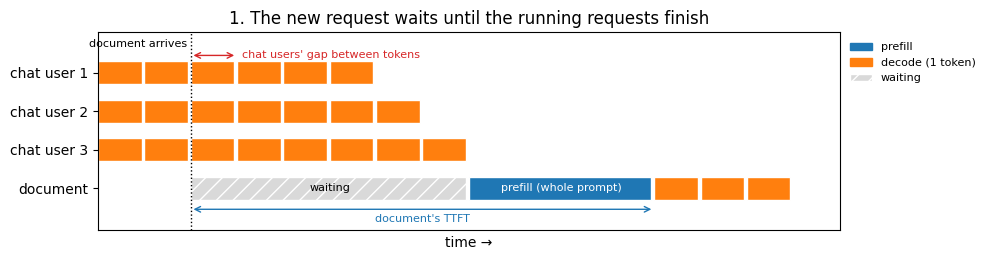

In [5]:
#@title Diagram
draw_schedule("wait", "1. The new request waits until the running requests finish")

The chat users are happy: nothing interrupts them, and they keep receiving a token
every ~40 ms. But the document has to wait until the *last* chat user finishes
before its prefill can even start. Notice also that the batch shrinks as chat
users finish one by one, so the GPUs do less and less useful work per step. In
our scenario, the document's TTFT becomes:

In [6]:
ttft_wait = (chat_done - 2.0) + prefill_time
print(f"document TTFT if it waits: {ttft_wait:.1f} s")

document TTFT if it waits: 9.3 s


Over 9 seconds before the user sees the first word of the summary, and almost all
of it is spent waiting, not computing. On a busy server it is even worse: there
is *always* someone decoding, so a new request could wait indefinitely
(*starvation*).

**Verdict: great TPOT, terrible TTFT.**

## What if... we pause the decodes and prefill right away?

The opposite policy: as soon as a new request arrives, pause everyone who is
decoding, run the new request's prefill on its own, then resume the decodes. This
*prefill-first* policy was the default in vLLM (Kwon et al., SOSP '23) before
its V1 engine.

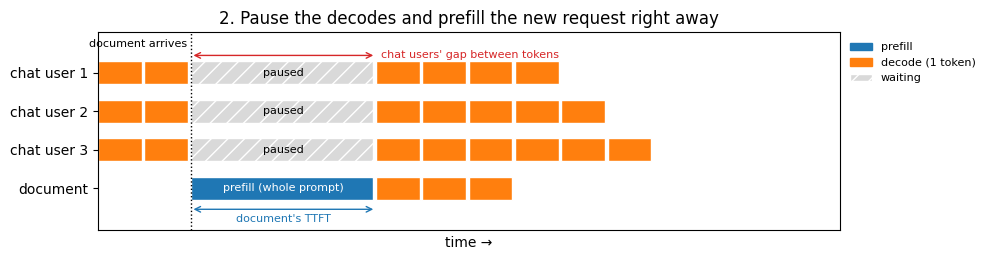

In [7]:
#@title Diagram
draw_schedule("pause", "2. Pause the decodes and prefill the new request right away")

Now the document gets its first token quickly: it only waits for the current
decode step to finish, then runs its 650 ms prefill. But during that prefill,
**none of the 16 chat users receives a token**. From each user's point of view,
the text stream freezes:

In [8]:
stall_pause = prefill_time + decode_step  # no token during the prefill, then the next decode step
print(f"document TTFT: ~{prefill_time:.2f} s")
print(f"longest gap between two tokens for a chat user: {1e3 * stall_pause:.0f} ms "
      f"(normally {1e3 * decode_step:.0f} ms)")

document TTFT: ~0.65 s
longest gap between two tokens for a chat user: 691 ms (normally 39 ms)


A 0.7 s freeze in the middle of a sentence is very noticeable, and it is not a
one-off: on a real server, long prompts keep arriving, and every one of them
freezes *every* user who is decoding at that moment. This is called a
**generation stall**, and it shows up as a high tail (p99) TPOT.

**Verdict: good TTFT, but every new prefill stalls everyone else.**

## What if... we batch the prefill and the decodes together?

Lecture 2 showed that batching is the key to efficiency. So why not put the new
prefill and the 16 decodes into the *same* step? The decodes then make progress
during the prefill instead of being paused. Orca (Yu et al., OSDI '22), which introduced
scheduling at the granularity of a single step (*iteration-level scheduling*),
could form such mixed batches.

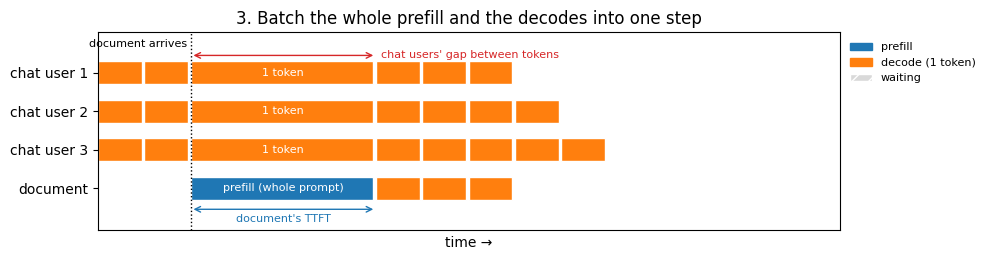

In [9]:
#@title Diagram
draw_schedule("mixed", "3. Batch the whole prefill and the decodes into one step")

Each chat user now gets one token out of the long step, instead of nothing. But
the step lasts as long as the whole prefill, so the gap between their tokens is
just as long as in policy 2.

This is what the simulator's scheduler does when its token budget per step
(`chunk_size`) is large enough to hold the whole prompt, e.g. 4,096 tokens. Let's
look at the steps around $t = 2$ s:

In [10]:
r_mixed, steps_mixed = run_scenario(chunk_size=4096)
cols = ["start (s)", "end (s)", "batch_num_prefill_tokens", "batch_num_decode_tokens",
        "batch_execution_time"]
steps_mixed[(steps_mixed["end (s)"] > 1.95) & (steps_mixed["start (s)"] < 2.8)][cols].round(3)

,start (s),end (s),batch_num_prefill_tokens,batch_num_decode_tokens,batch_execution_time
35,1.945,1.983,0,16,0.038
36,1.983,2.021,0,16,0.038
37,2.021,2.674,3800,16,0.653
38,2.674,2.710,0,17,0.036
39,2.710,2.746,0,17,0.036
40,2.746,2.781,0,17,0.036
41,2.781,2.817,0,17,0.036


Each row is one step. Before the document arrives, every step decodes 16 tokens
(one per chat user) in ~38 ms. Then one step processes all 3,800 prompt tokens
**plus** the 16 decode tokens, and takes about 650 ms. After that, the document
joins the decodes (17 per step).

Two observations:

1. **The decodes ride along almost for free.** The mixed step takes about as long
   as the prefill alone (compare with the 652 ms measured above). The prefill keeps
   the math units busy, and the 16 extra tokens add almost nothing to it.
2. **But the stall is still there.** Each chat user still gets only one token in
   that 650 ms step. A step cannot end before its biggest piece of work is done, so
   every request in the batch moves at the pace of the slowest one.

In [11]:
gap_mixed = steps_mixed["batch_execution_time"].max()
print(f"document TTFT: {r_mixed.ttft.iloc[16]:.2f} s")
print(f"longest gap between two tokens for a chat user: {1e3 * gap_mixed:.0f} ms")

document TTFT: 0.67 s
longest gap between two tokens for a chat user: 653 ms


**Verdict: slightly better than pausing, but the stall remains.**

## What do we actually want?

Looking back at the three attempts:

| Policy | Document TTFT | Chat users' longest gap | Problem |
|---|---|---|---|
| 1. New request waits | ~9 s | ~40 ms | new requests starve |
| 2. Pause decodes, prefill first | ~0.7 s | ~690 ms | everyone stalls |
| 3. Batch prefill and decodes together | ~0.7 s | ~650 ms | everyone still stalls |

The root cause in policies 2 and 3 is the same: a **single step that is very
long**, because it contains a whole long prompt. Policy 1 avoids long steps only
by refusing to make progress on the new request. What we want is:

- **every step stays short**, so decoding users keep receiving tokens at a steady pace;
- **every step still makes progress on the prefill**, so the new request is not
  starved.

## The solution: chunked prefill

Nothing forces us to prefill a prompt in one step. The prompt can be split into
**chunks**, processed over several consecutive steps. The first chunk computes the
KV cache of the first tokens; the next chunk attends to that cached KV and appends
its own, and so on. The result is exactly the same as prefilling the whole prompt
at once (this is the same mechanism decode uses to attend to earlier tokens).

**Chunked prefill**, introduced by Sarathi-Serve (Agrawal et al., OSDI '24) and
now used by default in vLLM and SGLang, builds every step under a fixed **token budget**
(`chunk_size` in our simulator):

1. Every request that is decoding gets its next token first (1 token each).
2. The remaining budget goes to prefills. A prompt longer than the remaining
   budget is cut, and the rest of it continues in the next step.

In the same diagram as before:

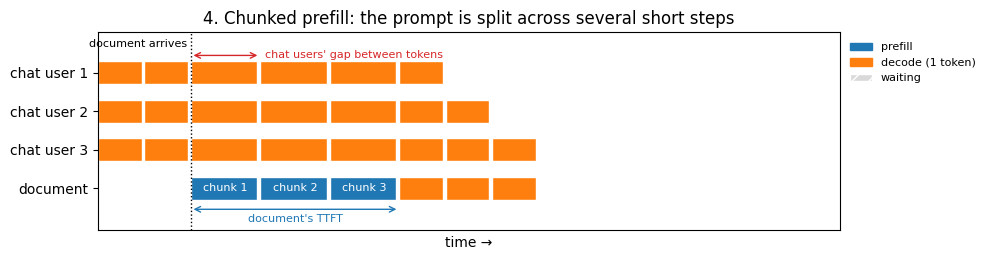

In [12]:
#@title Diagram
draw_schedule("chunked", "4. Chunked prefill: the prompt is split across several short steps")

Every step now contains a piece of the prefill *and* one token for every chat
user. Each step is a bit longer than a plain decode step, but none of them is
long, and the document still makes progress in every step. The cost is a
slightly later first token for the document, because its prefill is spread over
several steps.

With a budget of 512 tokens, each step in our scenario holds 16 decode tokens and
a 496-token chunk of the document:

In [13]:
r_chunk, steps_chunk = run_scenario(chunk_size=512)
steps_chunk[(steps_chunk["end (s)"] > 1.95) & (steps_chunk["start (s)"] < 2.9)][cols].round(3)

,start (s),end (s),batch_num_prefill_tokens,batch_num_decode_tokens,batch_execution_time
37,1.940,1.978,0,16,0.038
38,1.978,2.017,0,16,0.038
39,2.017,2.120,496,16,0.103
40,2.120,2.224,496,16,0.104
41,2.224,2.329,496,16,0.105
42,2.329,2.434,496,16,0.106
43,2.434,2.541,496,16,0.107
44,2.541,2.649,496,16,0.108
45,2.649,2.758,496,16,0.109
46,2.758,2.843,328,16,0.085


In [14]:
gap_chunk = steps_chunk["batch_execution_time"].max()
print(f"document TTFT: {r_chunk.ttft.iloc[16]:.2f} s")
print(f"longest gap between two tokens for a chat user: {1e3 * gap_chunk:.0f} ms")

document TTFT: 0.84 s
longest gap between two tokens for a chat user: 109 ms


The document is now prefilled over 8 steps of ~105 ms each. The chat users keep
receiving a token every ~105–110 ms instead of freezing for 650 ms, and the
document's TTFT grows only from ~0.67 s to ~0.84 s.

Why is the total cost so small? Look at the step times. A 512-token step takes
~105 ms, about the same as prefilling 512 tokens alone (lecture 2), yet it also
produces 16 decode tokens, which on their own would have needed a ~38 ms step.
Prefill chunks keep the math units busy, decodes need the memory bandwidth to
load the weights, and **a step that mixes them uses both**. Chunked prefill gets
the efficiency of batching (policy 3) without its long steps.

## Choosing the chunk size

The token budget is a knob, and it trades one latency against the other:

- A **smaller** budget makes every step shorter, so decoding users see smaller
  gaps. But the prompt is split into more steps, and every step has a fixed cost:
  it must load all the weights from memory, even if it processes few tokens. So the
  prefill takes longer in total, and TTFT grows.
- A **larger** budget prefills faster but makes steps longer. At 4,096, a whole
  3,800-token prompt fits in one step, and we are back to policy 3.

Let's run the scenario with different budgets:

In [15]:
rows = []
for c in [128, 256, 512, 1024, 2048, 4096]:
    r, st = run_scenario(chunk_size=c)
    rows.append({"chunk_size": c, "document TTFT (s)": r.ttft.iloc[16],
                 "chat users' longest gap (ms)": 1e3 * st["batch_execution_time"].max()})
budget = pd.DataFrame(rows).set_index("chunk_size")
budget.round(2)

,document TTFT (s),chat users' longest gap (ms)
chunk_size,,
128,1.59,47.52
256,1.06,64.95
512,0.84,109.30
1024,0.76,190.04
2048,0.67,342.25
4096,0.67,653.26


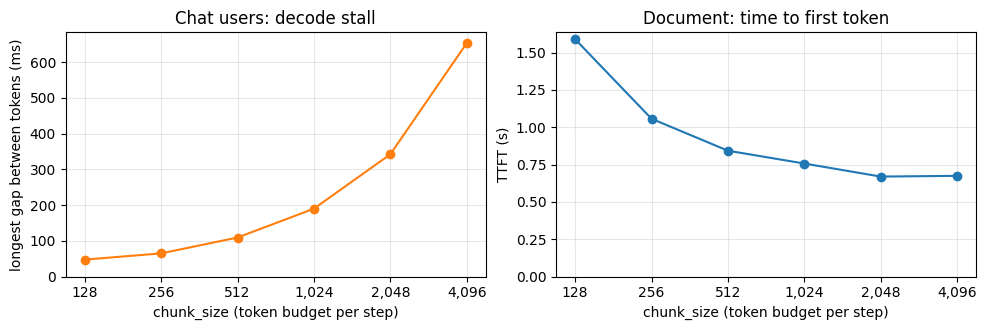

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(budget.index, budget["chat users' longest gap (ms)"], "o-", color="C1")
ax[0].set(ylabel="longest gap between tokens (ms)", title="Chat users: decode stall")
ax[1].plot(budget.index, budget["document TTFT (s)"], "o-", color="C0")
ax[1].set(ylabel="TTFT (s)", title="Document: time to first token")
for a in ax:
    a.set_xscale("log", base=2)
    a.set_xticks(budget.index, [f"{c:,}" for c in budget.index])
    a.minorticks_off()
    a.set_xlabel("chunk_size (token budget per step)")
    a.set_ylim(bottom=0)
fig.tight_layout()

Going from 4,096 down to 512 shrinks the stall by about 6× at a small cost in
TTFT. Below that, the returns diminish: a step can never be shorter than a plain
decode step (~38 ms), while TTFT keeps growing because the fixed per-step cost is
paid more and more times. In practice, budgets of a few hundred to a few thousand
tokens are common.

## Under real load

The scenario above had a single long prompt. On a real server, requests keep
arriving. We now simulate a mixed workload: 85% of requests are chat turns (256
tokens in, 256 out) and 15% are documents (3,800 tokens in, 32 out), arriving in
random order. `lsg.make_trace` writes the per-request lengths to a trace file that
the simulator replays.

In [17]:
rng = np.random.default_rng(0)
n = 300
is_long = rng.random(n) < 0.15
trace = lsg.make_trace(prefill_tokens=np.where(is_long, 3800, 256),
                      decode_tokens=np.where(is_long, 32, 256), n=n, name="mixed")
pd.read_csv(trace).value_counts().rename("requests")

num_prefill_tokens  num_decode_tokens
256                 256                  255
3800                32                    45
Name: requests, dtype: int64

We run the trace at a moderate load (2 req/s) and a heavy load (4 req/s),
sweeping `chunk_size` from 128 to 4,096 tokens per step. Since the stalls hit
only some of the tokens, we look at the **tail**: p99 TPOT.

In [18]:
chunks = [128, 256, 512, 1024, 2048, 4096]
cols = ["TTFT p50 (ms)", "TTFT p99 (ms)", "TPOT p50 (ms)", "TPOT p99 (ms)", "throughput (tok/s)"]
res = {q: lsg.sweep("chunk_size", chunks, **SYSTEM, trace=trace, num_requests=n, qps=q)
       for q in (2, 4)}
res[4][cols].round(0)

,TTFT p50 (ms),TTFT p99 (ms),TPOT p50 (ms),TPOT p99 (ms),throughput (tok/s)
chunk_size,,,,,
128.0,22589.0,41675.0,46.0,47.0,2541.0
256.0,5961.0,10664.0,65.0,66.0,3449.0
512.0,988.0,2993.0,83.0,103.0,3836.0
1024.0,567.0,2077.0,87.0,144.0,3856.0
2048.0,411.0,1768.0,87.0,158.0,3857.0
4096.0,423.0,2088.0,91.0,164.0,3854.0


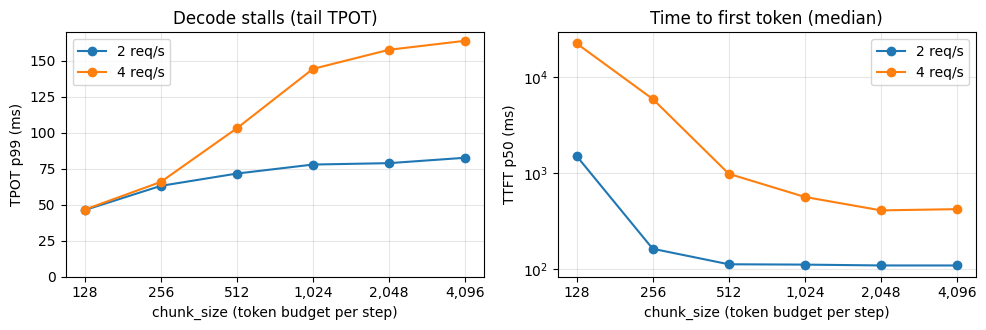

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for q, df in res.items():
    ax[0].plot(chunks, df["TPOT p99 (ms)"], "o-", label=f"{q} req/s")
    ax[1].plot(chunks, df["TTFT p50 (ms)"], "o-", label=f"{q} req/s")
ax[0].set(ylabel="TPOT p99 (ms)", title="Decode stalls (tail TPOT)", ylim=(0, None))
ax[1].set(ylabel="TTFT p50 (ms)", title="Time to first token (median)", yscale="log")
for a in ax:
    a.set_xscale("log", base=2)
    a.set_xticks(chunks, [f"{c:,}" for c in chunks])
    a.minorticks_off()
    a.set_xlabel("chunk_size (token budget per step)")
    a.legend()
fig.tight_layout()

Read the heavy-load (4 req/s) curves from right to left:

- **Large budget (4,096).** Every document is prefilled in one step, so every
  document stalls all the users decoding next to it. p99 TPOT is about 4× a plain
  decode step.
- **Medium budget (512).** Documents are split into ~8 chunks. p99 TPOT drops by
  about 40%, while median TTFT roughly doubles but stays under a second.
- **Tiny budget (128, 256).** Stalls almost disappear, but the steps are now so
  small that the fixed per-step cost dominates: the GPUs spend most of their time
  loading weights to process only a few tokens. Prefill throughput falls below the
  rate at which new prompts arrive, requests pile up in the queue, and TTFT
  explodes into many seconds.

At 2 req/s, the GPUs have spare capacity, so even tiny chunks keep up (except
128), and the stalls are milder because fewer documents arrive. **Scheduling
matters most when the system is busy**, and that is also when choosing the budget
is hardest.

## Who pays for the stall?

Finally, let's split TPOT by request type, with a medium and the largest budget.

In [20]:
loaded = {}
for c in (512, 4096):
    r = loaded[c] = lsg.simulate(**SYSTEM, trace=trace, num_requests=n, qps=4, chunk_size=c,
                                 keep_steps=True)
    kind = np.where(r.requests["request_num_prefill_tokens"] > 1000, "document", "chat")
    print(f"chunk_size={c}")
    print((1e3 * r.tpot.groupby(kind).describe(percentiles=[.5, .99])[["50%", "99%"]])
          .round(1).rename(columns={"50%": "TPOT p50 (ms)", "99%": "TPOT p99 (ms)"}), "\n")

chunk_size=512
          TPOT p50 (ms)  TPOT p99 (ms)
chat               82.2           96.5
document           92.7          103.6 



chunk_size=4096
          TPOT p50 (ms)  TPOT p99 (ms)
chat               91.5          108.2
document           86.2          173.6 



Look at the **chat** requests first. None of them has a long prompt, yet with the
large budget their TPOT is about 10% worse, only because they share steps with
*other users'* long prefills. The **documents** suffer most at the tail: they
produce only 32 tokens, so a single 650 ms stall caused by another document's
prefill raises their average TPOT a lot.

Note that TPOT is an *average* over a request's output tokens, so it hides how
bumpy the stream is. A chat user who sees one 650 ms freeze among 255 smooth
tokens has a TPOT only a few ms higher, but certainly notices the freeze. This
is why the scenario above measured the longest gap directly, and why some
systems also report the distribution of the **time between tokens** (TBT): the
gap before *each* output token, rather than one average per request.

We can compute TBT from the recorded steps. A decoding request receives one token
per step, so each decode token in a step waited exactly as long as that step took.
A step with 20 decode tokens therefore contributes 20 gaps of its duration:

In [21]:
tbt = {c: np.repeat(r.steps["batch_execution_time"].values,
                    r.steps["batch_num_decode_tokens"].values) for c, r in loaded.items()}
pd.DataFrame({f"chunk_size={c}": {
    "mean TPOT (ms)": round(1e3 * loaded[c].tpot.mean()),
    "mean TBT (ms)": round(1e3 * x.mean()),
    "TBT p50 (ms)": round(1e3 * np.percentile(x, 50)),
    "TBT p99 (ms)": round(1e3 * np.percentile(x, 99)),
    "tokens waiting > 300 ms": f"{(x > 0.3).mean():.1%}",
} for c, x in tbt.items()})

,chunk_size=512,chunk_size=4096
mean TPOT (ms),78,85
mean TBT (ms),78,85
TBT p50 (ms),104,42
TBT p99 (ms),109,706
tokens waiting > 300 ms,0.0%,5.6%


The mean TBT matches the mean TPOT, as it should: both are averages of the same
gaps. The two budgets differ by less than 10% on average, yet the percentiles
tell a very different story. A **cumulative distribution function** (CDF) shows
all of it at once: for every gap length on the x-axis, the curve gives the
fraction of tokens whose gap was at most that long. A curve that rises steeply and
early means consistently short gaps; a curve that creeps toward 1 far to the
right means a tail of long waits.

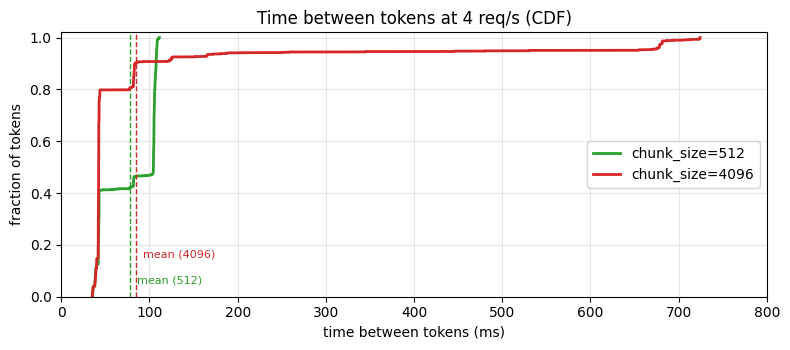

In [22]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for c, color in ((512, "C2"), (4096, "C3")):
    x = np.sort(1e3 * tbt[c])
    ax.plot(x, np.arange(1, len(x) + 1) / len(x), color=color, lw=2, label=f"chunk_size={c}")
    ax.axvline(1e3 * tbt[c].mean(), color=color, ls="--", lw=1)
    ax.text(1e3 * tbt[c].mean() + 8, 0.05 if c == 512 else 0.15, f"mean ({c})",
            color=color, fontsize=8)
ax.set(xlabel="time between tokens (ms)", ylabel="fraction of tokens", xlim=(0, 800),
       ylim=(0, 1.02), title="Time between tokens at 4 req/s (CDF)")
ax.legend(loc="center right")
fig.tight_layout()

The two dashed lines (the averages) are close, but the curves are not:

- **`chunk_size=4096`** (red) is *faster* for most tokens: about 80% of them
  come from plain decode steps of ~40 ms, because most steps contain no prefill at
  all. But the curve then flattens and only reaches 1 at ~700 ms. Those are the
  tokens stuck behind a whole 3,800-token prefill, about one token in twenty. A
  user reading the output sees the text freeze for most of a second, again and
  again.
- **`chunk_size=512`** (green) has two steps: ~40% of tokens come from plain
  decode steps (~40 ms), and the rest from steps that carry a prefill chunk
  (~105 ms). Prefill work is spread over many steps, so more tokens wait a bit
  longer, but the curve reaches 1 at ~110 ms: *no* token waits long.

The average cannot tell these two experiences apart; the CDF (or a high
percentile like p99) can. This is why serving systems state latency targets as
percentiles, and why the TBT tail, not the mean TPOT, is what chunked prefill
improves.

This **interference** between requests is what makes it hard to give latency
guarantees on a shared GPU, and chunked prefill is the first line of defense
against it.

## Summary

| Policy | TTFT | TPOT | Used by |
|---|---|---|---|
| New request waits for decodes | very bad (starvation) | good | FasterTransformer (request-level batching) |
| Pause decodes, prefill first | good | bad (stalls) | vLLM before V1 |
| Prefill + decodes in one step | good | bad (stalls) | Orca |
| **Chunked prefill** | slightly worse than above | slightly worse, tunable | Sarathi-Serve, vLLM V1, SGLang |

Chunked prefill bounds the work in every step with a token budget, so a long
prompt can no longer freeze everyone else, and it fills the leftover compute of
decode steps with useful prefill work. The budget (`chunk_size`) trades TTFT
against TPOT, and the trade-off is sharpest under heavy load.

## Exercises

:::{admonition} Try it
:class: exercise
1. In the scenario, replace the 3,800-token document with a 1,000-token one. How
   long is the stall with `chunk_size=4096`? With 512? Is chunking still worth it?
2. Raise the fraction of documents in the mixed workload to 40%. Does the best
   `chunk_size` for p99 TPOT change?
3. Suppose your SLO is p99 TTFT < 2 s **and** p99 TPOT < 100 ms. Find the
   largest `qps` you can sustain, and the `chunk_size` that achieves it.
:::

## Check your understanding

Click an answer to check it. Wrong answers can be retried.

In [23]:
#@title Questions (run this cell)
lsg.quiz([
    {"q": "A server makes every new request wait until all currently decoding requests finish. What goes wrong?",
     "options": ["TPOT of the decoding requests becomes very high",
                 "New requests can wait a very long time for their first token",
                 "The KV cache overflows"],
     "answer": 1,
     "explain": "The running requests are never interrupted, so their TPOT is fine. But a new request cannot even start its prefill until they all finish, and on a busy server someone is always decoding."},
    {"q": "A 4,000-token prompt arrives while 16 requests are decoding. The scheduler pauses the decodes and runs the prefill alone. What do the 16 users see?",
     "options": ["Nothing changes", "Their text stream freezes for about as long as the prefill takes",
                 "Their TTFT increases"],
     "answer": 1,
     "explain": "None of them receives a token during the prefill. Their TTFT is already past; what grows is the gap between two of their tokens (a generation stall)."},
    {"q": "Putting a whole 4,000-token prefill and 16 decodes into the same step…",
     "options": ["removes the stall, because the decodes make progress in the same step",
                 "still stalls the decodes, because the step lasts as long as the prefill",
                 "makes the prefill much slower"],
     "answer": 1,
     "explain": "The decodes do ride along almost for free, but each of them still gets only one token in a step that takes as long as the whole prefill."},
    {"q": "Why do decodes that share a step with a prefill chunk cost almost nothing extra?",
     "options": ["Decode tokens skip the attention layers",
                 "The step already loads all the weights for the chunk, so the decodes reuse them, and they add only a few FLOPs",
                 "The simulator ignores decode tokens in mixed steps"],
     "answer": 1,
     "explain": "Decode is memory-bound: its cost is loading the weights. In a mixed step that cost is already paid by the prefill chunk, and 16 extra tokens are tiny next to a 500-token chunk's arithmetic."},
    {"q": "Splitting a prompt into chunks over several steps changes the model's output.",
     "options": ["True", "False"], "answer": 1,
     "explain": "Each chunk attends to the KV cache written by earlier chunks, so the result is the same as prefilling the whole prompt at once."},
    {"q": "You reduce chunk_size from 4,096 to 512. What happens to p99 TPOT and to the TTFT of long prompts?",
     "options": ["Both decrease", "p99 TPOT decreases, long-prompt TTFT increases somewhat",
                 "p99 TPOT increases, long-prompt TTFT decreases", "Both increase"],
     "answer": 1,
     "explain": "Shorter steps mean shorter stalls for decoding users, but a long prompt now needs several steps to prefill."},
    {"q": "Under heavy load, a tiny chunk_size (e.g., 128) makes TTFT explode. Why?",
     "options": ["Every step must load all the weights, so tiny steps waste most of the GPU time and prefill throughput falls below the arrival rate",
                 "The KV cache cannot hold 128-token chunks",
                 "Decode requests are starved"],
     "answer": 0,
     "explain": "A step has a fixed cost of loading the weights. With tiny budgets that cost is paid for very few tokens, so prompts arrive faster than they can be prefilled, and the queue grows."},
    {"q": "Chat requests with short prompts get a worse p99 TPOT when the workload also contains long documents. Why?",
     "options": ["Their own prompts become longer",
                 "They share steps with other users' long prefills (interference)",
                 "Long documents use a different model"],
     "answer": 1,
     "explain": "A step is only as fast as its biggest piece of work. When a long prefill lands in a step, every request in that step waits for it."},
])